Author: Jennifer Flores 
# **Unsupervised Learning**
## **Searching for the Optimal Value of $k$ with K-Means**
### Dataset: Missing Persons

In this notebook, we will work with a **new dataset stored in Excel** and apply **K-Means Clustering** to discover natural groups in the data.

The main objective is:

> **Search the optimal value of $k$ for K-Means clustering on a new dataset.**

To select an appropriate value of $k$, we will mainly use:

- **Elbow Method**.
- **Silhouette Score**.
- A final visualization of the clusters using **PCA**.


### **1. Import the Required Packages**

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## **2. Load the Dataset**



In [9]:

file_path = r"C:\Documentos\2SEM2026\intelligence Artificial\lab assigment 1\mdi_personasdesaparecidas_pm_2026_enero_julio.xlsx"

In [12]:
excel_file = pd.ExcelFile(file_path)

print("Available sheets:")
for i, sheet in enumerate(excel_file.sheet_names):
    print(i, "->", sheet)


Available sheets:
0 -> Contenido
1 -> 1. Pdesaparecidas


In [13]:
sheet_name = None

for sheet in excel_file.sheet_names:
    if "pdesaparecidas" in sheet.lower():
        sheet_name = sheet
        break

if sheet_name is None:
    if len(excel_file.sheet_names) > 1:
        sheet_name = excel_file.sheet_names[1]
    else:
        sheet_name = excel_file.sheet_names[0]

print("Selected sheet:", sheet_name)

data = pd.read_excel(
    file_path,
    sheet_name=sheet_name
)

print("File read successfully.")


Selected sheet: 1. Pdesaparecidas
File read successfully.


## **3. Initial Dataset Exploration**

Before applying Machine Learning, we should understand the structure of the data.

In [ ]:
print("Original dimensions:", data.shape)
print("\nFirst 10 rows:")
display(data.head(10))


In [ ]:
print("Dataset information:")
data.info()


In [27]:
print("Original columns:")
for column in data.columns:
    print("-", column)


Original columns:
- fecha_desaparicion
- fecha_denuncia
- fecha_conocimiento
- zona
- distrito
- circuito
- subcircuito
- codigo_provincia
- provincia
- codigo_canton
- canton
- latitud
- longitud
- sexo
- nacionalidad
- edad
- rango_edad
- etnia
- fecha_localizacion
- latitud_localizacion
- longitud_localizacion
- provincia_localizacion
- situacion_actual
- motivacion
- motivacion_observada
- status


## **4. Dataset Cleaning**

We will remove:

- Completely empty rows.
- Completely empty columns.
- Columns whose names start with `Unnamed`.
- Unnecessary spaces in column names.


In [ ]:
# Create a copy to preserve the original data
clean_data = data.copy()

# Remove completely empty rows and columns
clean_data = clean_data.dropna(axis=0, how="all")
clean_data = clean_data.dropna(axis=1, how="all")

# Clean column names
clean_data.columns = [
    str(column).strip()
    for column in clean_data.columns
]

# Remove "Unnamed" columns
unnamed_columns = [
    column
    for column in clean_data.columns
    if column.lower().startswith("unnamed")
]

clean_data = clean_data.drop(
    columns=unnamed_columns,
    errors="ignore"
)

clean_data = clean_data.reset_index(drop=True)

print("Dimensions after cleaning:", clean_data.shape)
display(clean_data.head(10))




Excel may store some numerical columns as `object`. The following block attempts to convert them when at least 80% of their valid values appear to be numerical.

In [22]:
for column in clean_data.columns:

    if clean_data[column].dtype == "object":

        converted = pd.to_numeric(
            clean_data[column],
            errors="coerce"
        )

        original_valid = clean_data[column].notna().sum()
        converted_valid = converted.notna().sum()

        if original_valid > 0:

            ratio = converted_valid / original_valid

            if ratio >= 0.80:
                clean_data[column] = converted

print("Conversion completed.")


Conversion completed.


## **5. Identify Variable Types**

K-Means uses distances, so the variables must be converted into a numerical representation.

- **Numerical** variables will be imputed and standardized.
- **Categorical** variables will be imputed and encoded with `OneHotEncoder`.
- Date columns will be displayed, but they will not be used directly in this model.


In [23]:
numerical_columns = clean_data.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = clean_data.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

date_columns = clean_data.select_dtypes(
    include=["datetime", "datetimetz"]
).columns.tolist()

print("Numerical columns:", numerical_columns)
print("\nCategorical columns:", categorical_columns)
print("\nDate columns:", date_columns)


Numerical columns: ['codigo_provincia', 'codigo_canton', 'edad']

Categorical columns: ['zona', 'distrito', 'circuito', 'subcircuito', 'provincia', 'canton', 'latitud', 'longitud', 'sexo', 'nacionalidad', 'rango_edad', 'etnia', 'fecha_localizacion', 'latitud_localizacion', 'longitud_localizacion', 'provincia_localizacion', 'situacion_actual', 'motivacion', 'motivacion_observada', 'status']

Date columns: ['fecha_desaparicion', 'fecha_denuncia', 'fecha_conocimiento']


## **6. Remove Columns That Are Not Useful for Clustering**

A column such as an ID, unique code, full name, or record number may have almost one different value per row. This type of variable can distort K-Means.

The following block automatically detects **high-cardinality** categorical columns.

> After running the cell, review the list of removed columns to make sure it makes sense for your dataset.


In [24]:
high_cardinality_columns = []

for column in categorical_columns:

    unique_values = clean_data[column].nunique(dropna=True)
    valid_values = clean_data[column].notna().sum()

    if valid_values > 0:

        unique_ratio = unique_values / valid_values

        if unique_values > 30 and unique_ratio > 0.70:
            high_cardinality_columns.append(column)

print("Detected high-cardinality categorical columns:")
print(high_cardinality_columns)


Detected high-cardinality categorical columns:
['latitud', 'longitud']


### **7. Columns to Exclude Manually**

If you know that a column is an identifier, code, name, address, or another variable you do not want to use, add it to the `columns_to_exclude_manually` list.

Ejemplo:

```python
columns_to_exclude_manually = ["ID", "NAME"]
```


In [28]:
# You can edit this list if necessary
columns_to_exclude_manually = ["codigo_provincia",
    "codigo_canton","rango_edad","distrito",
"circuito",
"subcircuito","latitud_localizacion",
    "longitud_localizacion",
    "provincia_localizacion",
    "situacion_actual",
    "status"]

columns_to_exclude = list(
    set(
        high_cardinality_columns
        + date_columns
        + columns_to_exclude_manually
    )
)

model_data = clean_data.drop(
    columns=columns_to_exclude,
    errors="ignore"
)

print("Excluded columns:")
print(columns_to_exclude)

print("\nDimensions of the dataset used by K-Means:")
print(model_data.shape)


Excluded columns:
['fecha_denuncia', 'fecha_desaparicion', 'codigo_provincia', 'situacion_actual', 'longitud_localizacion', 'circuito', 'longitud', 'fecha_conocimiento', 'provincia_localizacion', 'codigo_canton', 'distrito', 'latitud_localizacion', 'status', 'subcircuito', 'latitud', 'rango_edad']

Dimensions of the dataset used by K-Means:
(4507, 10)


## **8. Preprocessing**

### Numerical Variables

1. Missing values are replaced with the **median**.
2. `StandardScaler` is applied so that all variables have a comparable scale.

Standardization is important because K-Means works with distances.

### Categorical Variables

1. Missing values are replaced with the most frequent category.
2. `OneHotEncoder` transforms each category into binary variables.


In [29]:
model_numerical_columns = model_data.select_dtypes(
    include=np.number
).columns.tolist()

model_categorical_columns = model_data.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print("Numerical variables used by the model:")
print(model_numerical_columns)

print("\nCategorical variables used by the model:")
print(model_categorical_columns)


Numerical variables used by the model:
['edad']

Categorical variables used by the model:
['zona', 'provincia', 'canton', 'sexo', 'nacionalidad', 'etnia', 'fecha_localizacion', 'motivacion', 'motivacion_observada']


In [35]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


In [38]:
from sklearn.compose import ColumnTransformer


transformers = []

if len(model_numerical_columns) > 0:
    transformers.append(
        (
            "numerical",
            numerical_pipeline,
            model_numerical_columns
        )
    )

if len(model_categorical_columns) > 0:
    transformers.append(
        (
            "categorical",
            categorical_pipeline,
            model_categorical_columns
        )
    )

if len(transformers) == 0:
    raise ValueError(
        "No useful variables were found for applying K-Means."
    )

preprocessor = ColumnTransformer(
    transformers=transformers
)

X = preprocessor.fit_transform(model_data)

print("Dimensions before preprocessing:", model_data.shape)
print("Dimensions after preprocessing:", X.shape)


Dimensions before preprocessing: (4507, 10)
Dimensions after preprocessing: (4507, 511)


## **9. First K-Means Test**

Before searching for the best $k$, we can observe what happens with an initial value, for example:

$$k=2$$

This value is only a demonstration and **does not mean that it is the optimal value**.


In [37]:
initial_model = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

initial_clusters = initial_model.fit_predict(X)

print("Inertia for k = 2:", initial_model.inertia_)
print("First labels:", initial_clusters[:20])


Inertia for k = 2: 27650.321389811666
First labels: [1 0 1 0 1 1 0 0 0 0 0 1 1 1 0 0 1 0 0 0]


## **10. Main Task: Search for the Optimal Value of $k$**

We will test several values of:

$$k = 2,3,4,\ldots,10$$

For each value, we will calculate:

### **Inertia**

Inertia measures the sum of the squared distances from observations to their centroids.

A lower inertia indicates more compact groups, but inertia always tends to decrease as $k$ increases.

### **Silhouette Score**

The Silhouette Score compares:

- How close an observation is to its own cluster.
- How well separated it is from other clusters.

Its approximate range is:

$$-1 \leq s \leq 1$$

A higher value usually indicates a better clustering structure.


In [39]:
number_of_samples = X.shape[0]

if number_of_samples < 3:
    raise ValueError(
        "The dataset has fewer than 3 observations and does not allow this search."
    )

max_k = min(10, number_of_samples - 1)
k_values = list(range(2, max_k + 1))

inertias = []
silhouette_scores = []

print("Results:")
print("-" * 65)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)

    inertia = model.inertia_
    inertias.append(inertia)

    actual_number_of_clusters = len(np.unique(labels))

    if 1 < actual_number_of_clusters < number_of_samples:
        silhouette = silhouette_score(X, labels)
    else:
        silhouette = np.nan

    silhouette_scores.append(silhouette)

    print(
        f"k = {k:2d} | "
        f"Inertia = {inertia:12.2f} | "
        f"Silhouette = {silhouette:.4f}"
    )


Results:
-----------------------------------------------------------------
k =  2 | Inertia =     27650.32 | Silhouette = 0.1413
k =  3 | Inertia =     25408.59 | Silhouette = 0.1055
k =  4 | Inertia =     23554.24 | Silhouette = 0.1331
k =  5 | Inertia =     22101.64 | Silhouette = 0.1313
k =  6 | Inertia =     21174.22 | Silhouette = 0.1374
k =  7 | Inertia =     20407.99 | Silhouette = 0.1380
k =  8 | Inertia =     19982.46 | Silhouette = 0.1347
k =  9 | Inertia =     19590.25 | Silhouette = 0.1251
k = 10 | Inertia =     19224.30 | Silhouette = 0.1191


## **11. Elbow Method**

We look for a point where the decrease in inertia becomes less pronounced. This change in slope visually forms an **elbow**.


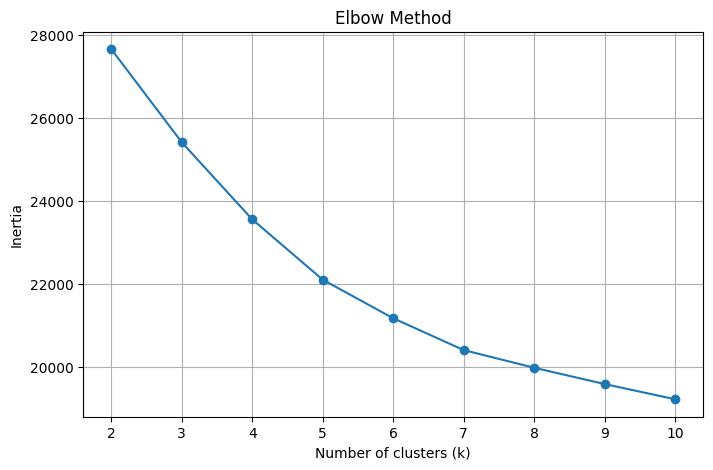

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertias,
    marker="o"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(k_values)
plt.grid()

plt.show()


## **12. Silhouette Method**

In this graph, we look for the value of $k$ with the **highest Silhouette Score**.


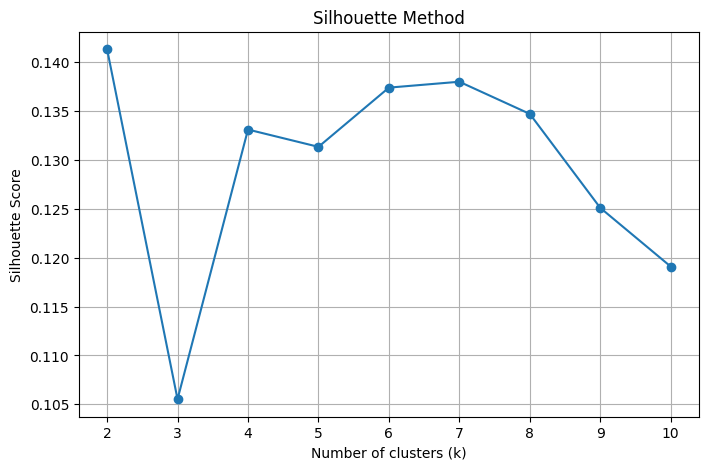

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.xticks(k_values)
plt.grid()

plt.show()


### **12.1 Automatic Selection of the Best $k$**

In this notebook, the value with the highest Silhouette Score is selected automatically.

The result should also be compared with the Elbow Method graph and with the interpretation of the problem.


In [42]:
silhouette_array = np.array(
    silhouette_scores,
    dtype=float
)

if np.all(np.isnan(silhouette_array)):
    raise ValueError(
        "It was not possible to calculate a valid Silhouette Score."
    )

best_position = np.nanargmax(silhouette_array)

best_k = k_values[best_position]
best_silhouette = silhouette_scores[best_position]

print("=" * 50)
print("RESULT")
print("=" * 50)
print("Best value of k according to Silhouette Score:", best_k)
print("Best Silhouette Score:", round(best_silhouette, 4))


RESULT
Best value of k according to Silhouette Score: 2
Best Silhouette Score: 0.1413


## **13. Train the Final Model**

Now we use the selected value of $k$ to train the final K-Means model.


In [43]:
kmeans_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans_model.fit_predict(X)

results = clean_data.copy()
results["Cluster"] = clusters

display(results.head(20))


,fecha_desaparicion,fecha_denuncia,fecha_conocimiento,zona,distrito,circuito,subcircuito,codigo_provincia,provincia,codigo_canton,...,etnia,fecha_localizacion,latitud_localizacion,longitud_localizacion,provincia_localizacion,situacion_actual,motivacion,motivacion_observada,status,Cluster
0,2026-07-31,2026-08-03,2026-08-03,ZONA 7,MACHALA,PÁEZ,PÁEZ 1,7,EL ORO,701,...,MESTIZO/A,NO_APLICA,NO_APLICA,NO_APLICA,NO_APLICA,DESAPARECIDO,NO_APLICA,NO_APLICA,EN INVESTIGACIÓN,1
1,2026-07-31,2026-08-01,2026-08-04,ZONA 8,9 DE OCTUBRE,CHILE,CHILE 4,9,GUAYAS,901,...,MESTIZO/A,NO_APLICA,NO_APLICA,NO_APLICA,NO_APLICA,DESAPARECIDO,NO_APLICA,NO_APLICA,EN INVESTIGACIÓN,0
2,2026-07-31,2026-08-03,2026-08-03,ZONA 2,RUMIÑAHUI - MEJÍA,FAJARDO,FAJARDO 2,17,PICHINCHA,1705,...,MESTIZO/A,NO_APLICA,NO_APLICA,NO_APLICA,NO_APLICA,DESAPARECIDO,NO_APLICA,NO_APLICA,EN INVESTIGACIÓN,1
3,2026-07-31,2026-07-31,2026-08-04,ZONA 8,ESTEROS,ESTEROS,ESTEROS 2,9,GUAYAS,901,...,MESTIZO/A,NO_APLICA,NO_APLICA,NO_APLICA,NO_APLICA,DESAPARECIDO,NO_APLICA,NO_APLICA,EN INVESTIGACIÓN,0
4,2026-07-31,2026-07-31,2026-07-31,ZONA 9,EUGENIO ESPEJO,SAN ISIDRO DEL INCA,SAN ISIDRO DEL INCA 4,17,PICHINCHA,1701,...,MESTIZO/A,2026/08/01,"-0,193758000000000014","-78,4663079999999979",PICHINCHA,ENCONTRADO,CAUSAS PERSONALES,CIRCUNSTANCIAL,DESAPARICIÓN VOLUNTARIA,1
5,2026-07-31,2026-08-01,2026-08-01,ZONA 9,MANUELA SÁENZ,MONJAS COLLACOTO,MONJAS COLLACOTO 2,17,PICHINCHA,1701,...,MESTIZO/A,2026/08/01,"0,238295487490065183","-78,4834260055501147",PICHINCHA,ENCONTRADO,CAUSAS PERSONALES,CIRCUNSTANCIAL,DESAPARICIÓN VOLUNTARIA,1
6,2026-07-31,2026-07-31,2026-07-31,ZONA 9,MANUELA SÁENZ,MONJAS COLLACOTO,MONJAS COLLACOTO 2,17,PICHINCHA,1701,...,MESTIZO/A,2026/08/03,"-1,46866500000000011","-77,9921599999999984",PASTAZA,ENCONTRADO,CAUSAS PERSONALES,CIRCUNSTANCIAL,DESAPARICIÓN VOLUNTARIA,0
7,2026-07-31,2026-08-02,2026-08-03,ZONA 8,PASCUALES,BASTIÓN POPULAR SUR,BASTIÓN POPULAR SUR 1,9,GUAYAS,901,...,MESTIZO/A,NO_APLICA,NO_APLICA,NO_APLICA,NO_APLICA,DESAPARECIDO,NO_APLICA,NO_APLICA,EN INVESTIGACIÓN,0
8,2026-07-31,2026-08-01,2026-08-01,ZONA 9,EUGENIO ESPEJO,EL BOSQUE,EL BOSQUE 5,17,PICHINCHA,1701,...,MESTIZO/A,2026/08/01,"-0,192689500000000014","-78,5134398999999945",PICHINCHA,ENCONTRADO,CAUSAS PERSONALES,CIRCUNSTANCIAL,DESAPARICIÓN VOLUNTARIA,0
9,2026-07-31,2026-08-07,2026-08-07,ZONA 9,CALDERÓN,CARAPUNGO,CARAPUNGO 3,17,PICHINCHA,1701,...,MESTIZO/A,2026/08/10,"-0,253989901556538278","-79,1761479261778192",SANTO DOMINGO DE LOS TSACHILAS,ENCONTRADO,EXTRAVIADO - AUSENCIA TEMPORAL,ACCIDENTAL POR DESCUIDO,EXTRAVÍO,0


### **13.1 Number of Observations in Each Cluster**

In [44]:
cluster_counts = (
    results["Cluster"]
    .value_counts()
    .sort_index()
)

print("Number of observations per cluster:")
display(cluster_counts.to_frame("Count"))


Number of observations per cluster:


,Count
Cluster,
0,1197
1,3310


## **14. Cluster Visualization Using PCA**

After preprocessing, we may have many variables.

**PCA (Principal Component Analysis)** allows us to reduce the data to two dimensions to create a visual representation.

> Important: PCA is used here only for visualization. K-Means was trained using all preprocessed variables.


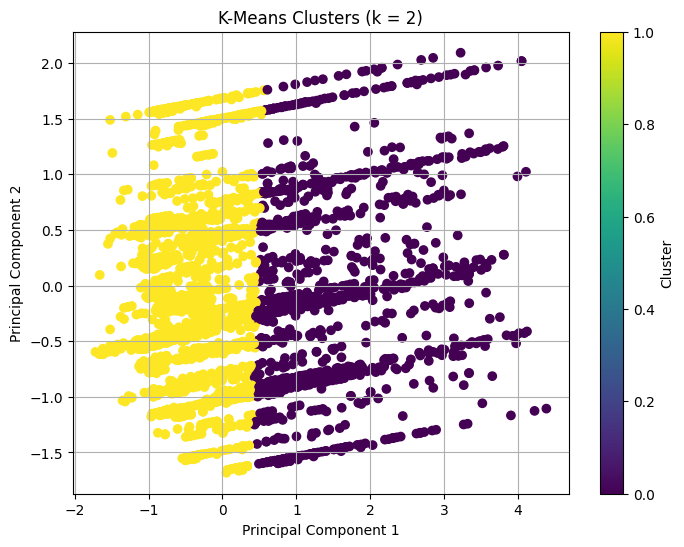

Variance explained by the two components: 0.2732


In [45]:
if X.shape[1] >= 2:

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=clusters
    )

    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title(f"K-Means Clusters (k = {best_k})")
    plt.colorbar(
        scatter,
        label="Cluster"
    )
    plt.grid()

    plt.show()

    print(
        "Variance explained by the two components:",
        round(pca.explained_variance_ratio_.sum(), 4)
    )

else:

    print(
        "There are not enough variables to create a 2D PCA visualization."
    )


## **15. Numerical Cluster Profile**

To interpret the groups, we can compare the means of the original numerical variables.

This helps answer questions such as:

- What characteristics distinguish one cluster from another?
- Are there groups with particularly high or low values?
- What pattern could each cluster represent?


In [46]:
result_numerical_columns = [
    column
    for column in model_numerical_columns
    if column in results.columns
]

if len(result_numerical_columns) > 0:

    cluster_profile = results.groupby(
        "Cluster"
    )[result_numerical_columns].mean()

    display(cluster_profile)

else:

    print(
        "There are no original numerical columns available to create this profile."
    )


,edad
Cluster,
0,46.280702
1,16.573889


## **Procedure Summary**

The workflow used was:

$$
\text{Excel}
\rightarrow
\text{Cleaning}
\rightarrow
\text{Preprocessing}
\rightarrow
\text{K-Means for different } k
\rightarrow
\text{Elbow + Silhouette}
\rightarrow
\text{Best } k
\rightarrow
\text{Final model}
\rightarrow
\text{Interpretation}
$$

Unsupervised learning does not receive a previously labeled correct answer. Instead, K-Means attempts to discover an internal structure in the data by grouping similar observations.
